<a href="https://colab.research.google.com/github/viti990/Physics-Informed-Neural-Networks/blob/main/SystemODEPINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
model = nn.Sequential(
       nn.Linear(in_features=1,out_features=64),
       nn.Tanh(),
       nn.Linear(in_features=64, out_features=64),
       nn.Tanh(),
       nn.Linear(in_features=64,out_features=64),
       nn.Tanh(),
       nn.Linear(in_features=64, out_features=2)
      )
model

Sequential(
  (0): Linear(in_features=1, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=2, bias=True)
)

In [3]:
def loss_fn(t, model, ic1, ic2):

  t = t.clone().detach().requires_grad_(True)
  # here it cannot be model(t)[:,0] it has to be [:,0:1] because of the format of the tensor, it cannot be (n,) it has to be (n,1)...
  x = model(t)[:,0:1]
  y = model(t)[:,1:2]

  dxdt = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
  dydt = torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]

  eq1 = dxdt + 2*x + y
  eq2 = dydt + 2*y + x

  loss_ode1 = torch.mean(torch.square(eq1))
  loss_ode2 = torch.mean(torch.square(eq2))
  # if the initial conditions are only scalar it can lead to problems, it is better to use the mean and also use them as tensors...
  loss_icx = torch.mean(torch.square(x[0] - ic1))
  loss_icy = torch.mean(torch.square(y[0] - ic2))

  return loss_ode1 + loss_ode2 + loss_icx + loss_icy

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

In [5]:
t_train = torch.tensor(np.linspace(0, 5, 100).reshape(-1,1), dtype=torch.float32)
ic1 = torch.tensor(np.array([1.0], dtype=np.float32).reshape(-1,1))
ic2 = torch.tensor(np.array([0.0], dtype=np.float32).reshape(-1,1))

In [6]:
torch.manual_seed(42)
epochs = 2000

for epoch in range(epochs):
  model.train()
  x_pred, y_pred = model(t_train).detach().T
  loss = loss_fn(t_train, model, ic1, ic2)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 500 == 0:
    #scheduler.step(loss)
    print(f"Epoch: {epoch} | Train loss: {loss}")

Epoch: 0 | Train loss: 1.3306652307510376
Epoch: 500 | Train loss: 9.643206431064755e-05
Epoch: 1000 | Train loss: 2.607145688671153e-05
Epoch: 1500 | Train loss: 4.507191988523118e-05


In [11]:
# Prediction using the trained model
t_test = torch.tensor(np.linspace(0, 5, 500).reshape(-1,1), dtype=torch.float32)
x_pred, y_pred = model(t_test).detach().T

In [12]:
# Analytical solutions
x_true = 0.5 * np.exp(-t_test) + 0.5 * np.exp(-3 * t_test)
y_true = -0.5 * np.exp(-t_test) + 0.5 * np.exp(-3 * t_test)

/tmp/ipykernel_44047/4293577505.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x_true = 0.5 * np.exp(-t_test) + 0.5 * np.exp(-3 * t_test)
/tmp/ipykernel_44047/4293577505.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = -0.5 * np.exp(-t_test) + 0.5 * np.exp(-3 * t_test)


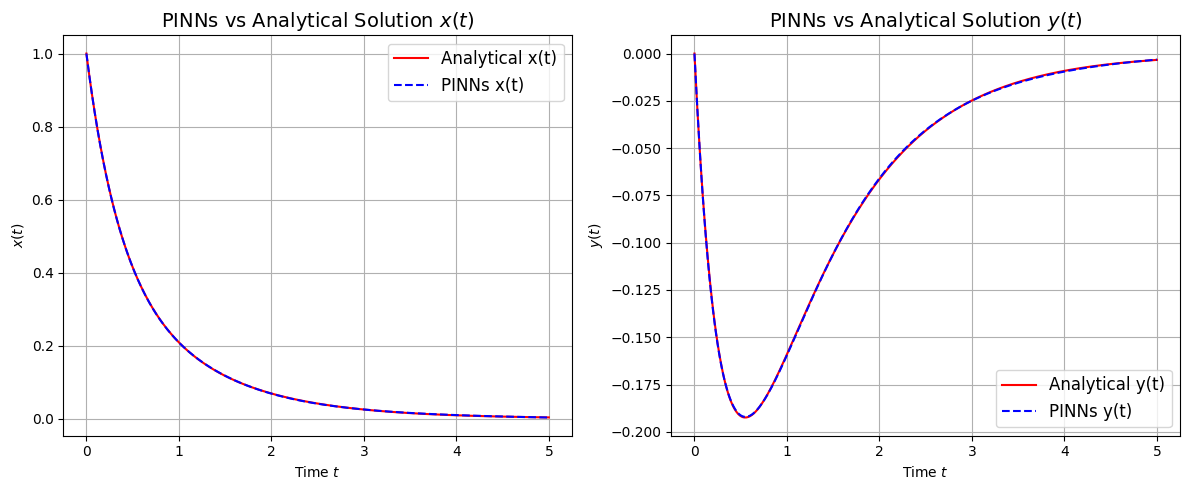

In [13]:
# Set up the plot with two subplots side by side
plt.figure(figsize=(12, 5))

# Plot x(t)
plt.subplot(1, 2, 1)
plt.plot(t_test, x_true, label='Analytical x(t)', color='red')
plt.plot(t_test, x_pred, '--', label='PINNs x(t)', color='blue')
plt.title(r'PINNs vs Analytical Solution $x(t)$', fontsize=14)
plt.xlabel(r'Time $t$')
plt.ylabel(r'$x(t)$')
plt.grid(True)
plt.legend(fontsize=12, loc="upper right")


# Plot y(t)
plt.subplot(1, 2, 2)
plt.plot(t_test, y_true, label='Analytical y(t)', color='red')
plt.plot(t_test, y_pred, '--', label='PINNs y(t)', color='blue')
plt.title(r'PINNs vs Analytical Solution $y(t)$', fontsize=14)
plt.xlabel(r'Time $t$')
plt.ylabel(r'$y(t)$')
plt.grid(True)
plt.legend(fontsize=12, loc="lower right")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()